# AI Algorithm - LLM Optimization with Block-wise SVD Genetic Algorithm
## Marcel YAMMINE, Anthony YANG, François ZAPLETAL - DIA6

In [1]:
!pip install transformers datasets accelerate
!pip install bitsandbytes
!pip install scipy

In [2]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import numpy as np
import copy
from tqdm import tqdm
import math
import random

## Load Model and Dataset

In [3]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.eval()  # no training here

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [39]:
dataset = load_dataset("glue", "sst2", split="validation[:200]")
train_dataset = load_dataset("glue", "sst2", split="validation[200:600]")
train_dataset_reduced = load_dataset("glue", "sst2", split="validation[200:400]")

In [40]:
# tokenize
def encode(batch):
    return tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=64)

dataset = dataset.map(encode, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [41]:
train_dataset = train_dataset.map(encode, batched=True)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
train_dataset_reduced = train_dataset_reduced.map(encode, batched=True)
train_dataset_reduced.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

## Evaluation Functions

In [7]:
@torch.no_grad()
def evaluate_accuracy(model, dataset):
    """ Function to evaluate the accuracy of the model """
    correct = 0
    total = 0

    for batch in dataset:
        inputs = {
            "input_ids": batch["input_ids"].unsqueeze(0),
            "attention_mask": batch["attention_mask"].unsqueeze(0)
        }
        labels = batch["label"].unsqueeze(0)

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == labels).sum().item()
        total += 1

    return correct / total

In [8]:
# The accuracy of the uncompressed model
baseline_acc = evaluate_accuracy(model, dataset)
print(f"Baseline accuracy: {baseline_acc:.4f}")

Baseline accuracy: 0.9100


In [9]:
def model_size_in_mb(model):
    """ Calculating the model size in MB """
    total = 0
    for param in model.parameters():
        total += param.nelement() * param.element_size()
    return total / (1024 * 1024)

In [10]:
# The size of the uncompressed model
baseline_size = model_size_in_mb(model)
print(f"Baseline size: {baseline_size:.4f} MB")

Baseline size: 255.4131 MB


## Layer Sensitivity Analysis

In [11]:
layers = []
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        layers.append((name, module))

print(f"Total layers: {len(layers)}")

Total layers: 38


In [12]:
def perturb_weights(weights, epsilon=0.1):
    noise = epsilon * torch.randn_like(weights)
    return weights + noise

In [13]:
layer_sensitivity = []

for layer_name, layer in tqdm(layers):
    # Save original weights
    original_w = layer.weight.data.clone()

    # Apply perturbation
    perturbed_w = perturb_weights(original_w, epsilon=0.1)
    layer.weight.data = perturbed_w

    # Evaluate
    acc = evaluate_accuracy(model, dataset)

    # Sensitivity score
    sensitivity = baseline_acc - acc
    layer_sensitivity.append((layer_name, sensitivity))

    # Restore original weights
    layer.weight.data = original_w

100%|██████████| 38/38 [04:50<00:00,  7.63s/it]


In [14]:
# Calculating the 10 least sensitive layers
layer_sensitivity_sorted = sorted(layer_sensitivity, key=lambda x: x[1])
print("10 least sensitive layers:")
for name, sens in layer_sensitivity_sorted[:10]:
    print(f"  {name}: {sens:.6f}")

10 least sensitive layers:
  distilbert.transformer.layer.5.ffn.lin1: -0.010000
  classifier: -0.005000
  distilbert.transformer.layer.5.attention.k_lin: 0.000000
  distilbert.transformer.layer.5.ffn.lin2: 0.000000
  distilbert.transformer.layer.1.attention.k_lin: 0.005000
  distilbert.transformer.layer.4.attention.v_lin: 0.005000
  distilbert.transformer.layer.5.attention.q_lin: 0.005000
  pre_classifier: 0.005000
  distilbert.transformer.layer.0.attention.q_lin: 0.010000
  distilbert.transformer.layer.0.attention.k_lin: 0.010000


## Block-wise SVD Compression Functions

In [15]:
def svd_compress(W, rank):
    """
    Apply SVD to compress weight matrix W to a given rank.
    """
    if rank >= min(W.shape):
        # If rank >= dimension, we return full SVD
        U, S, Vh = torch.linalg.svd(W, full_matrices=False)
        return U, S, Vh
    
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    U_r = U[:, :rank]
    S_r = S[:rank]
    Vh_r = Vh[:rank, :]
    
    return U_r, S_r, Vh_r

In [16]:
def block_svd_compress(W, block_shape, ranks):
    """
    Apply SVD compression to W in blocks.
    """
    rows, cols = W.shape
    b_rows, b_cols = block_shape
    
    compressed_blocks = []
    block_idx = 0
    
    # Iterate over the matrix in blocks
    for i in range(0, rows, b_rows):
        for j in range(0, cols, b_cols):
            r_end = min(i + b_rows, rows)
            c_end = min(j + b_cols, cols)
            
            # Extract the block
            W_block = W[i:r_end, j:c_end]
            
            # Determine rank for this block
            if isinstance(ranks, list):
                if block_idx >= len(ranks):
                    raise ValueError(f"Not enough ranks provided.")
                current_rank = ranks[block_idx]
            else:
                current_rank = ranks
            
            # Compress the block
            U_r, S_r, Vh_r = svd_compress(W_block, current_rank)
            
            # Save the block at this position
            compressed_blocks.append({
                'U': U_r,
                'S': S_r,
                'V': Vh_r,
                'position': (i, r_end, j, c_end),
                'rank': current_rank
            })
            
            block_idx += 1
    
    return compressed_blocks

In [17]:
class BlockLowRankLinear(nn.Module):
    """
    Linear layer with SVD per blocks.
    Stock each bloc in decompostion format (U, S, V).
    """
    def __init__(self, compressed_blocks, original_shape, bias=None):
        super().__init__()
        self.original_shape = original_shape  # (out_features, in_features)
        self.compressed_blocks = compressed_blocks

        for i, block in enumerate(compressed_blocks):
            self.register_parameter(f'U_{i}', nn.Parameter(block['U']))
            self.register_parameter(f'S_{i}', nn.Parameter(block['S']))
            self.register_parameter(f'V_{i}', nn.Parameter(block['V']))
        
        if bias is not None:
            self.bias = nn.Parameter(bias)
        else:
            self.register_parameter('bias', None)
    
    def forward(self, x):
        # Construsct the compressed matrix
        rows, cols = self.original_shape
        W_reconstructed = torch.zeros(rows, cols, device=x.device, dtype=x.dtype)
        
        for i, block in enumerate(self.compressed_blocks):
            U = getattr(self, f'U_{i}')
            S = getattr(self, f'S_{i}')
            V = getattr(self, f'V_{i}')
            
            i_start, i_end, j_start, j_end = block['position']
            
            # Construct the block
            W_block = U @ torch.diag(S) @ V
            W_reconstructed[i_start:i_end, j_start:j_end] = W_block
        
        output = torch.matmul(x, W_reconstructed.T)
        
        if self.bias is not None:
            output = output + self.bias
        
        return output

In [18]:
def apply_block_compression_to_layer(layer, block_shape, ranks):
    """
    Replace the Linear layer by a BlockLowRankLinear
    """
    if not isinstance(layer, torch.nn.Linear):
        print(f"Skipping: Layer is {type(layer)}, not Linear.")
        return None
    
    W = layer.weight.data
    bias = layer.bias.data if layer.bias is not None else None
    
    # Compression per blocks
    compressed_blocks = block_svd_compress(W, block_shape, ranks)
    
    # Create a new layer
    new_layer = BlockLowRankLinear(compressed_blocks, W.shape, bias)
    
    return new_layer

In [19]:
def get_block_configuration_from_number_of_blocks(layer, nb_blocks=8):
    """
    Calculates the shape of the blocks in a layer to determine the genome size
    """
    if isinstance(layer, torch.nn.Linear):
        rows, cols = layer.weight.shape
    else:
        rows, cols = layer.shape
    
    if nb_blocks <= 1:
        return (rows, cols)
    
    aspect_ratio = rows / cols
    grid_h = int(math.sqrt(nb_blocks * aspect_ratio))
    grid_h = max(1, grid_h)
    
    grid_w = int(nb_blocks / grid_h)
    grid_w = max(1, grid_w)
    
    block_height = math.ceil(rows / grid_h)
    block_width = math.ceil(cols / grid_w)
    
    return (block_height, block_width)

In [20]:
def initilisation_ranks(nb_blocks, block_size, min_rank=1, max_rank=32):
    """Initialize random ranks for each block"""
    ranks = [random.randint(min_rank, max_rank) for i in range(nb_blocks)]
    return ranks

## Genetic Algorithm with Block-wise SVD

In [21]:
def random_chromosome(layers, possible_nb_blocks, min_rank=1, max_rank=32):
    """
    Each chromosome is:
    nb_blocks = int and ranks = []
    """
    chrom = {}
    for layer_name, layer_obj in layers:
        nb_blocks = random.choice(possible_nb_blocks)
        ranks = initilisation_ranks(nb_blocks, None, min_rank, max_rank)
        
        chrom[layer_name] = {
            "nb_blocks": nb_blocks,
            "ranks": ranks
        }
    
    return chrom

In [22]:
def apply_chromosome(model, chromosome):
    """
    Apply compression defined by chromosome to a copy of the model.
    """
    compressed_model = copy.deepcopy(model)
    
    for layer_name, config in chromosome.items():
        nb_blocks = config["nb_blocks"]
        ranks = config["ranks"]
        
        # Find and replace the layer
        parent_name = '.'.join(layer_name.split('.')[:-1])
        child_name = layer_name.split('.')[-1]
        
        # Access to parent module
        parent_module = compressed_model
        for part in parent_name.split('.'):
            if part:
                parent_module = getattr(parent_module, part)
        
        # Recover the original layer
        original_layer = getattr(parent_module, child_name)
        
        if isinstance(original_layer, torch.nn.Linear):
            # Calculate the block shape
            block_shape = get_block_configuration_from_number_of_blocks(
                original_layer, nb_blocks
            )
            
            # Create the new compressed layer
            compressed_layer = apply_block_compression_to_layer(
                original_layer, block_shape, ranks
            )
            
            # replace the layer and the model
            setattr(parent_module, child_name, compressed_layer)
    
    return compressed_model

In [23]:
def fitness_scorer(acc, size, baseline_acc, baseline_size, lam=0.5):
    """Normalized accuracy - size tradeoff"""
    return (acc / baseline_acc) - lam * (size / baseline_size)

In [24]:
def evaluate_chromosome(model, chromosome, dataset):
    """
    Evaluate a chromosome using fitness_scorer.
    """
    compressed_model = apply_chromosome(model, chromosome)
    
    acc = evaluate_accuracy(compressed_model, dataset)
    size = model_size_in_mb(compressed_model)
    
    fitness = fitness_scorer(acc, size, baseline_acc, baseline_size, lam=0.5)
    
    return fitness, acc, size

In [25]:
def crossover(parent1, parent2):
    """
    Single-point crossover between two chromosomes.
    """
    child = {}
    
    layer_names = list(parent1.keys())
    crossover_point = random.randint(1, len(layer_names) - 1)
    
    for i, layer_name in enumerate(layer_names):
        if i < crossover_point:
            child[layer_name] = copy.deepcopy(parent1[layer_name])
        else:
            child[layer_name] = copy.deepcopy(parent2[layer_name])
    
    return child

In [26]:
def mutate(chromosome, possible_nb_blocks, min_rank=1, max_rank=32, mutation_rate=0.1):
    """
    Mutate a chromosome.
    - Change nb_blocks with probability mutation_rate
    - Change individual ranks with probability mutation_rate
    """
    mutated = copy.deepcopy(chromosome)
    
    for layer_name in mutated:
        # Mutate nb_blocks
        if random.random() < mutation_rate:
            new_nb_blocks = random.choice(possible_nb_blocks)
            mutated[layer_name]["nb_blocks"] = new_nb_blocks
            # Regenerate ranks for new number of blocks
            mutated[layer_name]["ranks"] = initilisation_ranks(new_nb_blocks, None, min_rank, max_rank)
        else:
            # Mutate individual ranks
            ranks = mutated[layer_name]["ranks"]
            for i in range(len(ranks)):
                if random.random() < mutation_rate:
                    ranks[i] = random.randint(min_rank, max_rank)
    
    return mutated

In [27]:
def genetic_algorithm(
    model,
    dataset,
    layers,
    possible_nb_blocks=[1, 2, 4, 8],
    min_rank=1,
    max_rank=32,
    population_size=10,
    generations=5,
    mutation_rate=0.1,
    elite_size=2
):
    """
    Genetic Algorithm for optimizing block-wise SVD compression.
    """
    print("\n" + "="*60)
    print("Genetic Algorithm : Block-wise SVD Optimization")
    print("="*60)
    print(f"Population size: {population_size}")
    print(f"Generations: {generations}")
    print(f"Mutation rate: {mutation_rate}")
    print(f"Elite size: {elite_size}")
    print(f"Fitness function: fitness_scorer ")
    print("="*60 + "\n")
    
    # Initialize population
    population = [random_chromosome(layers, possible_nb_blocks, min_rank, max_rank) 
                  for _ in range(population_size)]
    
    best_fitness_history = []
    best_overall = None
    best_fitness_overall = float('-inf')
    
    for gen in range(generations):
        print(f"\nGeneration {gen + 1}/{generations}")
        print("-" * 60)
        
        # Evaluate population
        fitness_scores = []
        for i, chrom in enumerate(population):
            fitness, acc, size = evaluate_chromosome(model, chrom, dataset)
            fitness_scores.append((fitness, acc, size, chrom))
            
            if (i + 1) % 5 == 0:
                print(f"Evaluated {i+1}/{population_size} chromosomes")
        
        # Sort by fitness (descending)
        fitness_scores.sort(key=lambda x: x[0], reverse=True)
        
        # Best of generation
        best_fitness, best_acc, best_size, best_chrom = fitness_scores[0]
        print(f"\n  Best fitness: {best_fitness:.6f}")
        print(f"  Accuracy: {best_acc:.4f}")
        print(f"  Size: {best_size:.2f} MB")
        
        best_fitness_history.append(best_fitness)
        
        # Update overall best
        if best_fitness > best_fitness_overall:
            best_fitness_overall = best_fitness
            best_overall = copy.deepcopy(best_chrom)
            print(f"New overall best!")
        
        # Selection: keep elite
        new_population = [copy.deepcopy(x[3]) for x in fitness_scores[:elite_size]]
        
        # Generate offspring
        while len(new_population) < population_size:
            # Tournament selection
            parent1 = random.choice(fitness_scores[:population_size // 2])[3]
            parent2 = random.choice(fitness_scores[:population_size // 2])[3]
            
            # Crossover
            child = crossover(parent1, parent2)
            
            # Mutation
            child = mutate(child, possible_nb_blocks, min_rank, max_rank, mutation_rate)
            
            new_population.append(child)
        
        population = new_population
    
    print("\n" + "="*60)
    print("Optimization complete")
    print("="*60)
    print(f"Best overall fitness: {best_fitness_overall:.6f}")
    print("="*60 + "\n")
    
    return best_overall, best_fitness_history

## Run Genetic Algorithm

In [28]:
# Select N least sensitive layers to compress
N_LAYERS = 5
selected_layers = layer_sensitivity_sorted[:N_LAYERS]

print(f"\nSelected {N_LAYERS} least sensitive layers for compression:")
for name, sens in selected_layers:
    print(f"  {name}: sensitivity = {sens:.6f}")


Selected 5 least sensitive layers for compression:
  distilbert.transformer.layer.5.ffn.lin1: sensitivity = -0.010000
  classifier: sensitivity = -0.005000
  distilbert.transformer.layer.5.attention.k_lin: sensitivity = 0.000000
  distilbert.transformer.layer.5.ffn.lin2: sensitivity = 0.000000
  distilbert.transformer.layer.1.attention.k_lin: sensitivity = 0.005000


In [29]:
# Run Genetic Algorithm
best_chromosome, fitness_history = genetic_algorithm(
    model=model,
    dataset=train_dataset,
    layers=selected_layers,
    possible_nb_blocks=[ 4, 8, 16],
    min_rank=1,
    max_rank=32,
    population_size=10,
    generations=5,
    mutation_rate=0.2,
    elite_size=2
)


Genetic Algorithm : Block-wise SVD Optimization
Population size: 10
Generations: 5
Mutation rate: 0.2
Elite size: 2
Fitness function: fitness_scorer 


Generation 1/5
------------------------------------------------------------
Evaluated 5/10 chromosomes
Evaluated 10/10 chromosomes

  Best fitness: 0.548202
  Accuracy: 0.9175
  Size: 235.00 MB
New overall best!

Generation 2/5
------------------------------------------------------------
Evaluated 5/10 chromosomes
Evaluated 10/10 chromosomes

  Best fitness: 0.550946
  Accuracy: 0.9200
  Size: 235.00 MB
New overall best!

Generation 3/5
------------------------------------------------------------
Evaluated 5/10 chromosomes
Evaluated 10/10 chromosomes

  Best fitness: 0.550946
  Accuracy: 0.9200
  Size: 235.00 MB

Generation 4/5
------------------------------------------------------------
Evaluated 5/10 chromosomes
Evaluated 10/10 chromosomes

  Best fitness: 0.550946
  Accuracy: 0.9200
  Size: 235.00 MB

Generation 5/5
----------------

## Evaluate Best Solution

In [30]:
# Apply best chromosome to model
final_model = apply_chromosome(model, best_chromosome)

# Evaluate
final_acc = evaluate_accuracy(final_model, dataset)
final_size = model_size_in_mb(final_model)
baseline_size = model_size_in_mb(model)

print("\n" + "="*60)
print("Final Results")
print("="*60)
print(f"Baseline:")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"  Size: {baseline_size:.2f} MB")
print(f"\nOptimized Model:")
print(f"  Accuracy: {final_acc:.4f}")
print(f"  Size: {final_size:.2f} MB")
print(f"\nImprovements:")
print(f"  Accuracy drop: {(baseline_acc - final_acc):.4f} ({((baseline_acc - final_acc) / baseline_acc * 100):.2f}%)")
print(f"  Size reduction: {(baseline_size - final_size):.2f} MB ({((baseline_size - final_size) / baseline_size * 100):.2f}%)")
print(f"  Compression ratio: {(baseline_size / final_size):.2f}x")
print("="*60)


Final Results
Baseline:
  Accuracy: 0.9100
  Size: 255.41 MB

Optimized Model:
  Accuracy: 0.9050
  Size: 234.76 MB

Improvements:
  Accuracy drop: 0.0050 (0.55%)
  Size reduction: 20.66 MB (8.09%)
  Compression ratio: 1.09x


In [31]:
# Display best chromosome configuration
print("\nBest Chromosome Configuration:")
print("-" * 60)
for layer_name, config in best_chromosome.items():
    print(f"\nLayer: {layer_name}")
    print(f"  Number of blocks: {config['nb_blocks']}")
    print(f"  Ranks: {config['ranks']}")


Best Chromosome Configuration:
------------------------------------------------------------

Layer: distilbert.transformer.layer.5.ffn.lin1
  Number of blocks: 16
  Ranks: [5, 27, 30, 20, 26, 2, 19, 32, 7, 26, 12, 16, 17, 27, 2, 8]

Layer: classifier
  Number of blocks: 4
  Ranks: [10, 10, 4, 17]

Layer: distilbert.transformer.layer.5.attention.k_lin
  Number of blocks: 4
  Ranks: [30, 25, 3, 15]

Layer: distilbert.transformer.layer.5.ffn.lin2
  Number of blocks: 16
  Ranks: [16, 31, 12, 10, 3, 23, 3, 3, 3, 8, 7, 8, 25, 30, 28, 1]

Layer: distilbert.transformer.layer.1.attention.k_lin
  Number of blocks: 8
  Ranks: [22, 6, 8, 21, 1, 1, 2, 30]


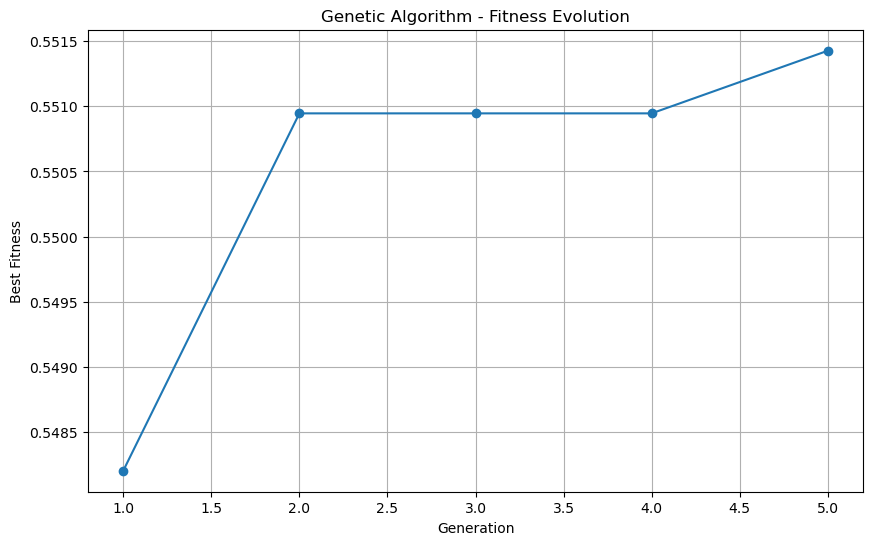

In [32]:
# Plot fitness evolution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(fitness_history) + 1), fitness_history, marker='o')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Genetic Algorithm - Fitness Evolution')
plt.grid(True)
plt.show()

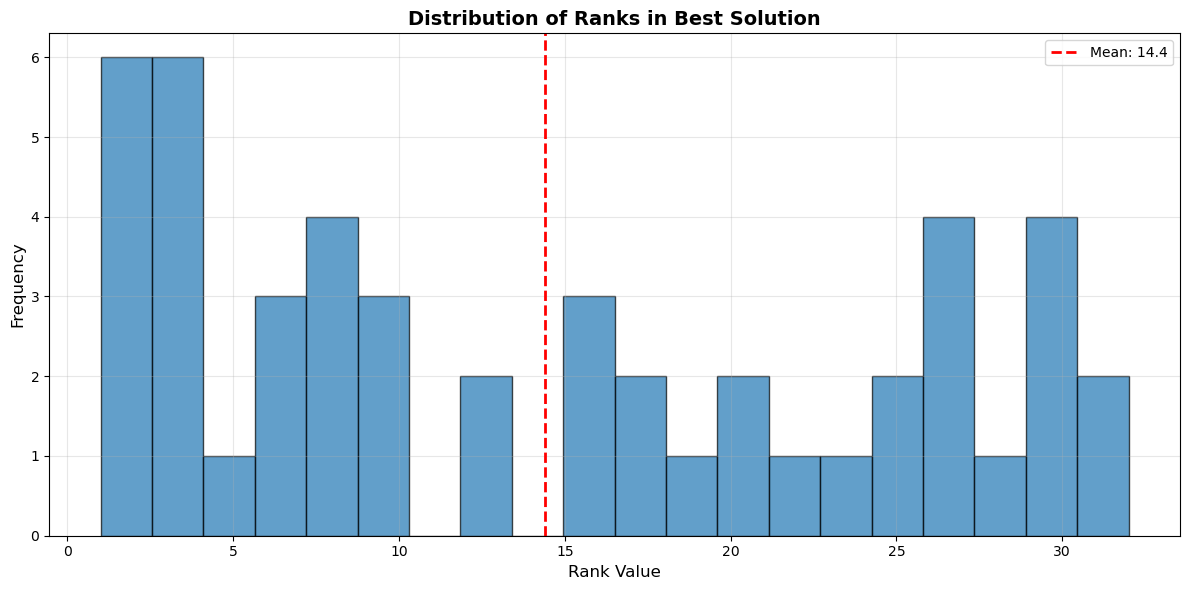

In [33]:
# Extract all the ranks of the best chromosome
all_ranks = []
layer_names = []

for layer_name, config in best_chromosome.items():
    all_ranks.extend(config['ranks'])
    layer_names.append(layer_name.split('.')[-1])  # Nom court

plt.figure(figsize=(12, 6))
plt.hist(all_ranks, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Rank Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Ranks in Best Solution', fontsize=14, fontweight='bold')
plt.axvline(x=np.mean(all_ranks), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_ranks):.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

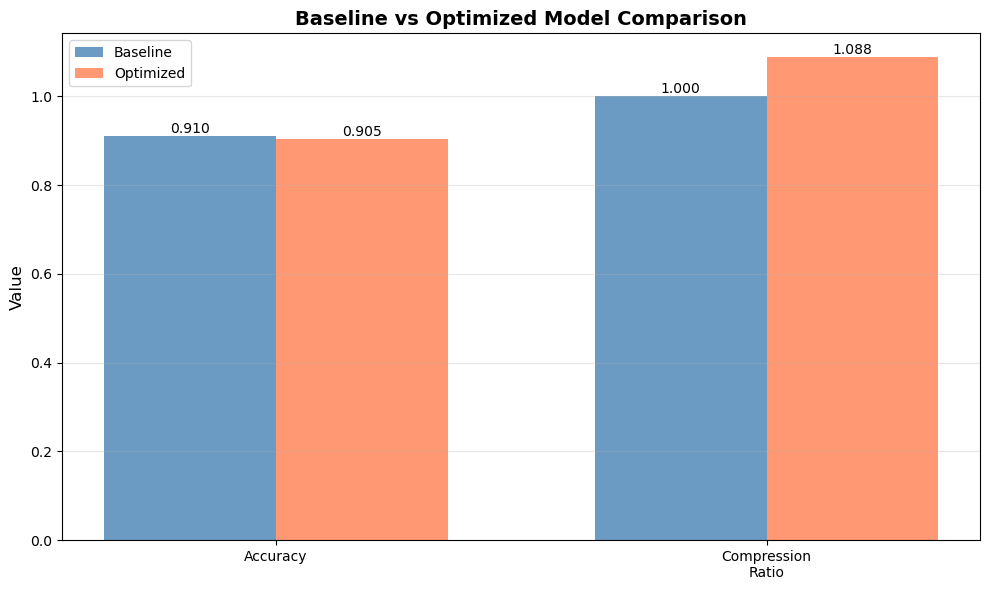

In [34]:
metrics = ['Accuracy', 'Compression\nRatio']
baseline_values = [baseline_acc, 1.0]
optimized_values = [final_acc, baseline_size / final_size]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, optimized_values, width, label='Optimized', alpha=0.8, color='coral')

ax.set_ylabel('Value', fontsize=12)
ax.set_title('Baseline vs Optimized Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add values on the plots
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\Francis\AppData\Local\Temp\ipykernel_18992\3637307392.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


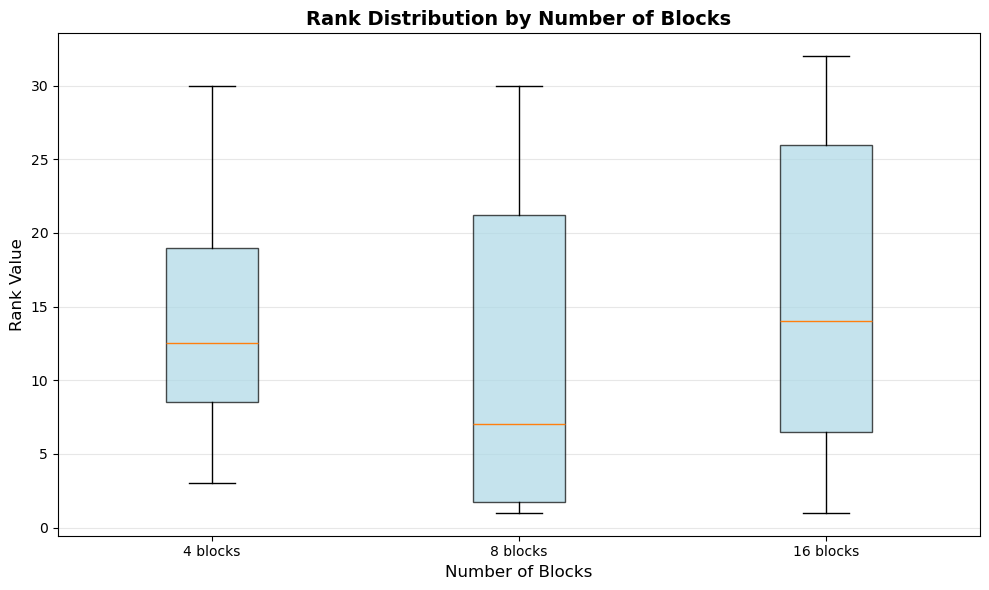

In [36]:
# Merge ranks by nb_blocks
ranks_by_nb_blocks = {}

for layer_name, config in best_chromosome.items():
    nb_blocks = config['nb_blocks']
    if nb_blocks not in ranks_by_nb_blocks:
        ranks_by_nb_blocks[nb_blocks] = []
    ranks_by_nb_blocks[nb_blocks].extend(config['ranks'])

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [ranks_by_nb_blocks[nb] for nb in sorted(ranks_by_nb_blocks.keys())]
labels = [f'{nb} blocks' for nb in sorted(ranks_by_nb_blocks.keys())]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_xlabel('Number of Blocks', fontsize=12)
ax.set_ylabel('Rank Value', fontsize=12)
ax.set_title('Rank Distribution by Number of Blocks', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Study for different nb_blocks

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define parameters to test
blocks_options = [[4], [8], [16]]

results = []
all_ranks_data = []

print(f"Starting study (3 experiments)")

# --- 1. Calculer la Baseline une seule fois au début ---
print("\nCalculating Baseline metrics...")
baseline_acc = evaluate_accuracy(model, dataset)
baseline_size = model_size_in_mb(model)
print(f"Baseline Accuracy: {baseline_acc:.4f} | Size: {baseline_size:.2f} MB")

# Experiment Loop
for blocks in blocks_options:
    nb_blocks_val = blocks[0]
    exp_name = f"Blocks={nb_blocks_val}"
    print(f"\n--- Running: {exp_name} ---")
    
    # Run Genetic Algorithm
    best_chrom, fitness_hist = genetic_algorithm(
        model=model,
        dataset=train_dataset_reduced,
        layers=selected_layers,
        possible_nb_blocks=blocks, 
        min_rank=1,
        max_rank=32,
        population_size=5,
        generations=5,
        mutation_rate=0.2,
        elite_size=2
    )
    
    # Evaluate final result
    final_model = apply_chromosome(model, best_chrom)
    final_acc = evaluate_accuracy(final_model, dataset)
    final_size = model_size_in_mb(final_model)
    
    # Display blocks of final results
    print("\n" + "="*60)
    print(f"Final Results for {exp_name}")
    print("="*60)
    print(f"Baseline:")
    print(f"  Accuracy: {baseline_acc:.4f}")
    print(f"  Size: {baseline_size:.2f} MB")
    print(f"\nOptimized Model ({exp_name}):")
    print(f"  Accuracy: {final_acc:.4f}")
    print(f"  Size: {final_size:.2f} MB")
    print(f"\nImprovements:")
    # Calcul des deltas
    acc_drop = baseline_acc - final_acc
    acc_drop_pct = (acc_drop / baseline_acc) * 100
    size_red = baseline_size - final_size
    size_red_pct = (size_red / baseline_size) * 100
    comp_ratio = baseline_size / final_size
    
    print(f"  Accuracy drop: {acc_drop:.4f} ({acc_drop_pct:.2f}%)")
    print(f"  Size reduction: {size_red:.2f} MB ({size_red_pct:.2f}%)")
    print(f"  Compression ratio: {comp_ratio:.2f}x")
    print("="*60)
    # ----------------------------------------------------

    # Store General Results
    results.append({
        "Nb_Blocks": str(nb_blocks_val),
        "Final_Accuracy": final_acc,
        "Final_Size_MB": final_size,
        "Fitness_History": fitness_hist,
        "Best_chrom": best_chrom,
        "Label": exp_name,
        "Compression_Ratio": comp_ratio
    })

    # We iterate through the best solution to extract the ranks chosen for each layer
    for layer_name, config in best_chrom.items():
        ranks = config['ranks']
        for r in ranks:
            all_ranks_data.append({
                "Nb_Blocks": str(nb_blocks_val), # Category
                "Rank_Value": r                  # The rank chosen
            })

# Convert data to DataFrames
df_results = pd.DataFrame(results)
df_ranks = pd.DataFrame(all_ranks_data)
print("\nExperiments finished! Generating plots...")

Starting study (3 experiments)

Calculating Baseline metrics...
Baseline Accuracy: 0.9100 | Size: 255.41 MB

--- Running: Blocks=4 ---

Genetic Algorithm : Block-wise SVD Optimization
Population size: 5
Generations: 5
Mutation rate: 0.2
Elite size: 2
Fitness function: fitness_scorer 


Generation 1/5
------------------------------------------------------------
Evaluated 5/5 chromosomes

  Best fitness: 0.553221
  Accuracy: 0.9200
  Size: 233.84 MB
New overall best!

Generation 2/5
------------------------------------------------------------
Evaluated 5/5 chromosomes

  Best fitness: 0.553525
  Accuracy: 0.9200
  Size: 233.68 MB
New overall best!

Generation 3/5
------------------------------------------------------------
Evaluated 5/5 chromosomes

  Best fitness: 0.553525
  Accuracy: 0.9200
  Size: 233.68 MB

Generation 4/5
------------------------------------------------------------
Evaluated 5/5 chromosomes

  Best fitness: 0.558905
  Accuracy: 0.9250
  Size: 233.74 MB
New overall be

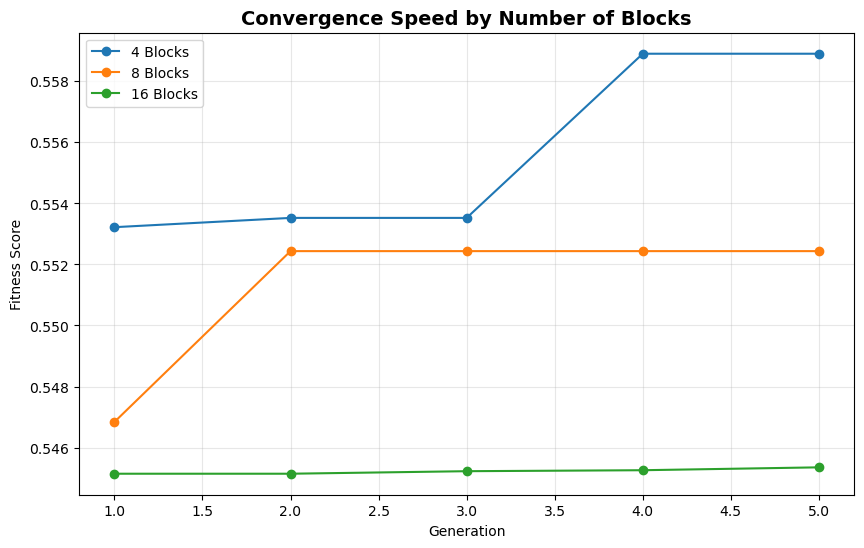

In [54]:

# Convergence Speed
plt.figure(figsize=(10, 6))
for i, row in df_results.iterrows():
    plt.plot(range(1, len(row['Fitness_History']) + 1), 
             row['Fitness_History'], 
             marker='o', 
             label=f"{row['Nb_Blocks']} Blocks")

plt.title('Convergence Speed by Number of Blocks', fontsize=14, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Fitness Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

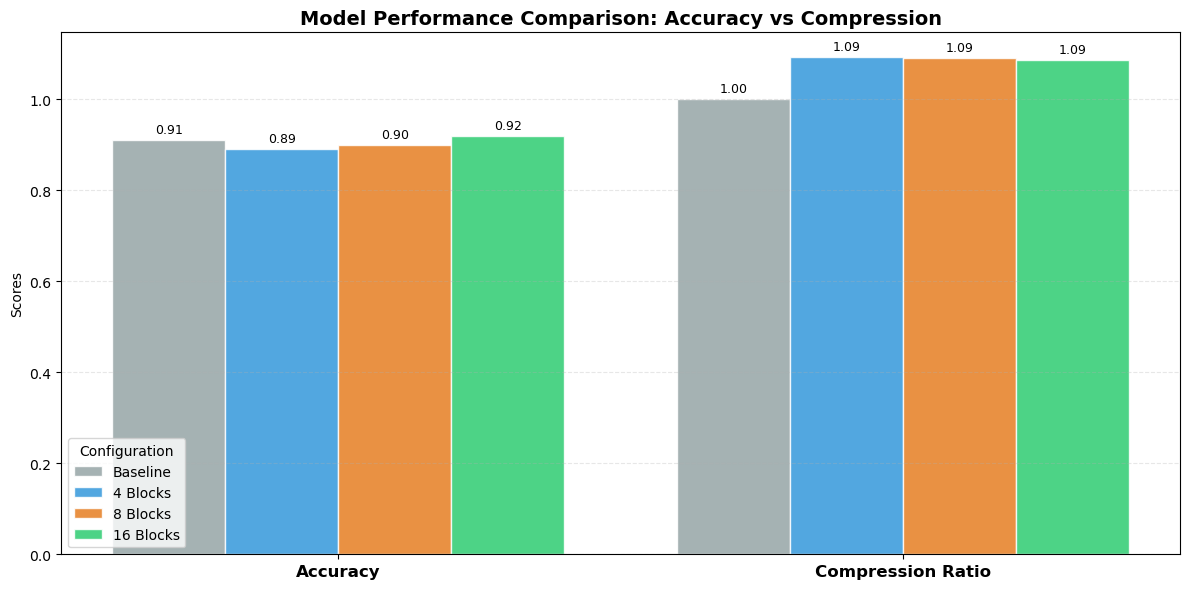

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
df_sorted = df_results.sort_values(by="Nb_Blocks", key=lambda x: x.astype(int))

# Accuracy values
acc_list = [baseline_acc] + df_sorted['Final_Accuracy'].tolist()

# Compression Ratio values (Baseline / Compressed)
# Ratio > 1 means compression. E.g., 250MB / 125MB = 2.0x compression
ratio_list = [1.0] + [baseline_size / s for s in df_sorted['Final_Size_MB'].tolist()]

# Configuration names for legend
configs = ['Baseline'] + [f"{nb} Blocks" for nb in df_sorted['Nb_Blocks']]

# Plotting
x_labels = ['Accuracy', 'Compression Ratio']
x = np.arange(len(x_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Define offsets for 4 bars centered around 0
offsets = [-1.5, -0.5, 0.5, 1.5]
colors = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71'] # Grey, Blue, Orange, Green

for i, config_name in enumerate(configs):
    # Data for this configuration across the two metrics
    values = [acc_list[i], ratio_list[i]]
    
    # Create bars
    rects = ax.bar(x + offsets[i] * width, values, width, label=config_name, color=colors[i], alpha=0.85, edgecolor='white')
    
    # Add labels
    ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=9)

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison: Accuracy vs Compression', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.legend(title="Configuration")
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

C:\Users\Francis\AppData\Local\Temp\ipykernel_18992\2941118515.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ranks, x="Nb_Blocks", y="Rank_Value", palette="Set2")


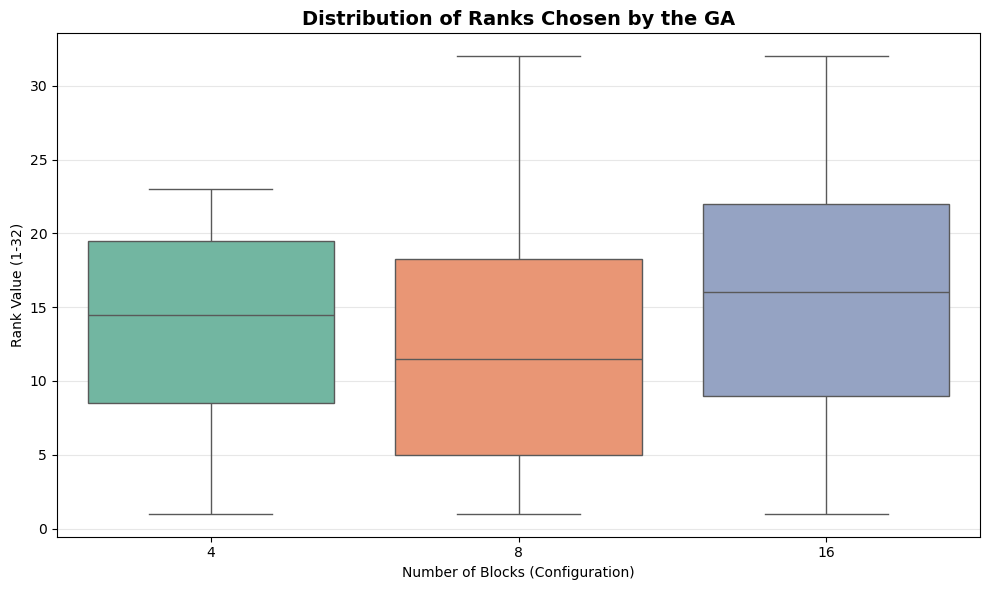

In [56]:

# Rank Distribution (Boxplot)
plt.figure(figsize=(10, 6))

# Boxplot to show the spread of ranks chosen by the GA
sns.boxplot(data=df_ranks, x="Nb_Blocks", y="Rank_Value", palette="Set2")

plt.title('Distribution of Ranks Chosen by the GA', fontsize=14, fontweight='bold')
plt.xlabel('Number of Blocks (Configuration)')
plt.ylabel('Rank Value (1-32)')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()